# Email Spam Detection

## Step 1 — Import Libraries and Dataset

In this step, we load the dataset and inspect its basic structure.

In [1108]:
import pandas as pd

df = pd.read_csv('/home/ahmed/.cache/kagglehub/datasets/jackksoncsie/spam-email-dataset/versions/1/emails.csv')

df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [1109]:
import pandas as pd

df = pd.read_csv('/home/ahmed/.cache/kagglehub/datasets/jackksoncsie/spam-email-dataset/versions/1/emails.csv')

df.columns

Index(['text', 'spam'], dtype='str')

In [1110]:
df.shape

(5728, 2)

In [1111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


In [1112]:
df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [1113]:
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

# Step 2 — Data Cleaning

In [1114]:
df.shape

(5728, 2)

In [1115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


In [1116]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [1117]:
df.duplicated().sum()

np.int64(33)

In [1118]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [1119]:
df = df.dropna(subset=["text", "spam"])

In [1120]:
df.duplicated().sum()

np.int64(33)

In [1121]:
df[df.duplicated()].head()

,text,spam
2155,Subject: research allocations to egm hi becky...,0
2260,Subject: departure of grant masson the resear...,0
2412,"Subject: re : schedule and more . . jinbaek ,...",0
2473,"Subject: day off tuesday stinson , i would l...",0
2763,"Subject: re : your mail zhendong , dr . kami...",0


In [1122]:
df = df.drop_duplicates()

In [1123]:
df.duplicated().sum()

np.int64(0)

In [1124]:
(df["text"].astype(str).str.strip() == "").sum()

np.int64(0)

In [1125]:
df = df[df["text"].astype(str).str.strip() != ""]

In [1126]:
df["spam"].unique()

array([1, 0])

In [1127]:
df["spam"].value_counts(dropna=False)

spam
0    4327
1    1368
Name: count, dtype: int64

In [1128]:
df["text"].dtype

<StringDtype(storage='python', na_value=nan)>

In [1129]:
df["text"].head()

0    Subject: naturally irresistible your corporate...
1    Subject: the stock trading gunslinger  fanny i...
2    Subject: unbelievable new homes made easy  im ...
3    Subject: 4 color printing special  request add...
4    Subject: do not have money , get software cds ...
Name: text, dtype: str

In [1130]:
(df["text"].astype(str).str.len()).describe()

count     5695.000000
mean      1558.067076
std       2047.078711
min         13.000000
25%        508.500000
50%        979.000000
75%       1893.000000
max      43952.000000
Name: text, dtype: float64

In [1131]:
df = df.dropna(subset=["text", "spam"])

In [1132]:
df = df.drop_duplicates()

In [1133]:
df = df[df["text"].astype(str).str.strip() != ""]

In [1134]:
print("Shape: ", df.shape)

Shape:  (5695, 2)


In [1135]:
print("\nMissing values: ")
print(df.isnull().sum())


Missing values: 
text    0
spam    0
dtype: int64


In [1136]:
print("\nDuplicates: ")
print(df.duplicated().sum())


Duplicates: 
0


In [1137]:
print("\nLabels:")
print(df.value_counts(dropna=False))


Labels:
text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [1138]:
print("\nEmail lengths:")
print(df['text'].astype(str).str.len().describe())


Email lengths:
count     5695.000000
mean      1558.067076
std       2047.078711
min         13.000000
25%        508.500000
50%        979.000000
75%       1893.000000
max      43952.000000
Name: text, dtype: float64


In [1139]:
df["spam"].value_counts(dropna=False)

spam
0    4327
1    1368
Name: count, dtype: int64

## Step 3 — Distribution of Labels

In [1140]:
label_counts = df.value_counts()
print(label_counts)

text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [1141]:
label_percentages = (df["spam"].value_counts(normalize=True)) * 100
print(label_percentages)

spam
0    75.978929
1    24.021071
Name: proportion, dtype: float64


In [1142]:
label_names = df['spam'].map({
    0: "Ham",
    1: "Spam"
})

label_names.head()

0    Spam
1    Spam
2    Spam
3    Spam
4    Spam
Name: spam, dtype: str

/tmp/ipykernel_43825/3032231013.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=label_names, order = ["Ham", "Spam"], palette={"Ham": "#4CAF50", "Spam": "#FF5722"},)


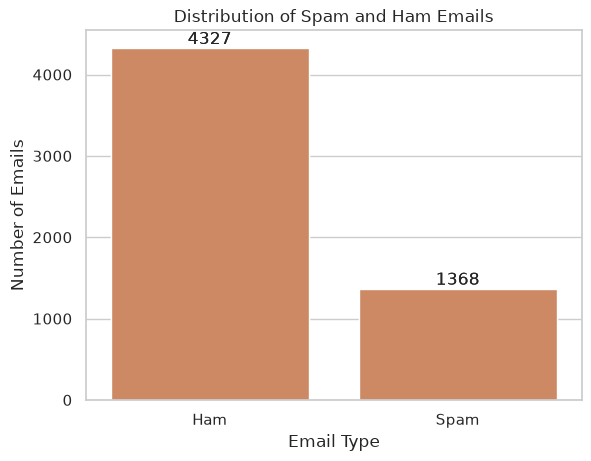

In [1143]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
sns.countplot(x=label_names, order = ["Ham", "Spam"], palette={"Ham": "#4CAF50", "Spam": "#FF5722"},)
ax = sns.countplot(x = label_names)
plt.title("Distribution of Spam and Ham Emails")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")

for container in ax.containers:
    ax.bar_label(container)
    
plt.show()


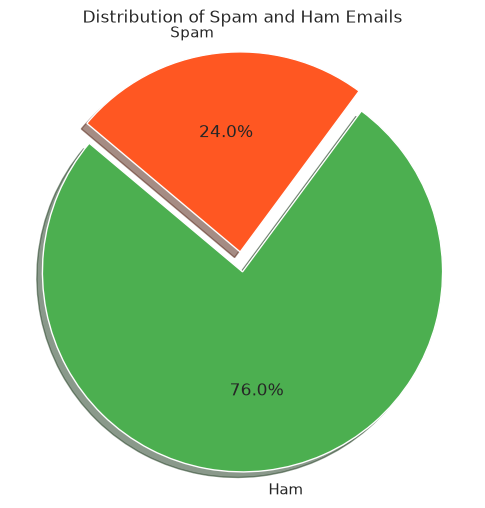

In [1144]:
class_counts = df['spam'].value_counts()
labels = ['Ham', 'Spam']
sizes = [class_counts[0], class_counts[1]] 
colors = ['#4CAF50', '#FF5722']
explode = (0, 0.1)
plt.figure(figsize=(6, 6))

plt.pie(
    sizes, 
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    shadow=True,
    startangle=140
)

plt.title("Distribution of Spam and Ham Emails")
plt.axis('equal')
plt.show()

In [1145]:
df["text_length"] = df["text"].str.len()

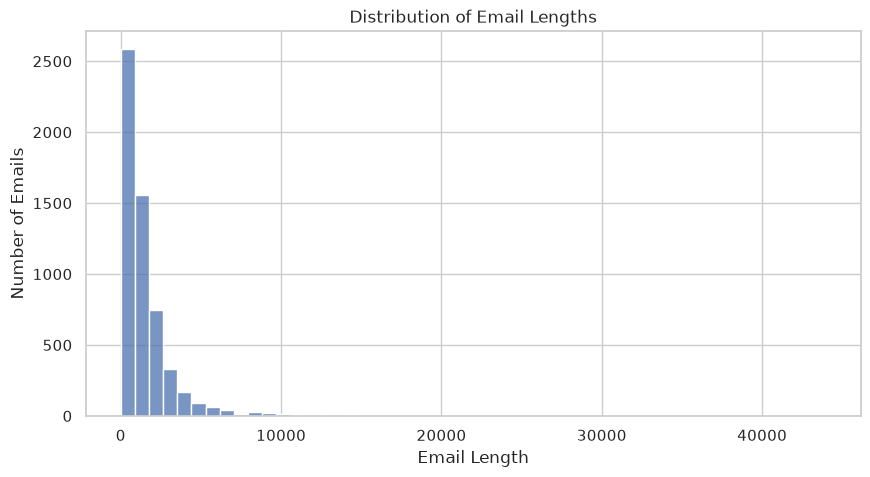

In [1146]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x= "text_length",
    bins = 50
)

plt.title("Distribution of Email Lengths")
plt.xlabel("Email Length")
plt.ylabel("Number of Emails")
plt.show()

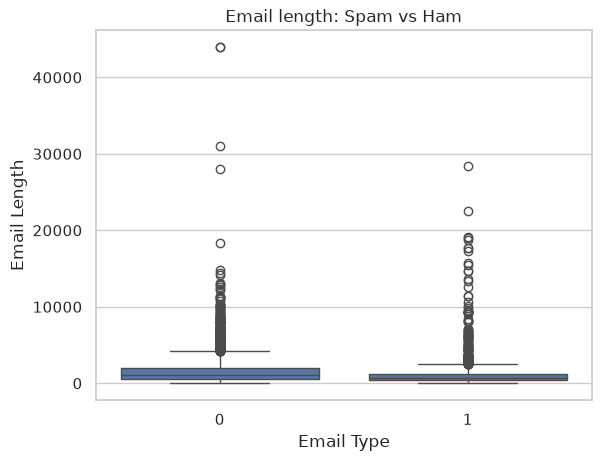

In [1147]:
sns.boxplot(
    data= df,
    x="spam",
    y="text_length"
)

plt.title("Email length: Spam vs Ham")
plt.xlabel("Email Type")
plt.ylabel("Email Length")

plt.show()

## Step 4 — Preprocessing: Cleaning the Junk

In [1148]:
df['text'].head(10)

0    Subject: naturally irresistible your corporate...
1    Subject: the stock trading gunslinger  fanny i...
2    Subject: unbelievable new homes made easy  im ...
3    Subject: 4 color printing special  request add...
4    Subject: do not have money , get software cds ...
5    Subject: great nnews  hello , welcome to medzo...
6    Subject: here ' s a hot play in motion  homela...
7    Subject: save your money buy getting this thin...
8    Subject: undeliverable : home based business f...
9    Subject: save your money buy getting this thin...
Name: text, dtype: str

In [1149]:
df[df['spam'] == 1]['text'].head(5)

0    Subject: naturally irresistible your corporate...
1    Subject: the stock trading gunslinger  fanny i...
2    Subject: unbelievable new homes made easy  im ...
3    Subject: 4 color printing special  request add...
4    Subject: do not have money , get software cds ...
Name: text, dtype: str

In [1150]:
df[df['spam'] == 0]['text'].head(5)

1368    Subject: hello guys ,  i ' m " bugging you " f...
1369    Subject: sacramento weather station  fyi  - - ...
1370    Subject: from the enron india newsdesk - jan 1...
1371    Subject: re : powerisk 2001 - your invitation ...
1372    Subject: re : resco database and customer capt...
Name: text, dtype: str

In [1151]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [1152]:
sample = """
CONGRATULATIONS!!! <b>You WON $500!</b>
Visit https://example.com/claim NOW!!!
"""

print(clean_text(sample))

congratulations you won 500 visit now


In [1153]:
for i in range(5):
    print("="*80)
    sample_email = df['text'].iloc[i]
    print("\nOriginal text:")
    print(sample_email)

    print("\nCleaned text:")
    print(clean_text(sample_email))


Original text:
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordabi

In [1154]:
df['clean_text'] = df["text"].apply(clean_text)

In [1155]:
df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: naturally irresistible your corporate...,subject naturally irresistible your corporate ...
1,Subject: the stock trading gunslinger fanny i...,subject the stock trading gunslinger fanny is ...
2,Subject: unbelievable new homes made easy im ...,subject unbelievable new homes made easy im wa...
3,Subject: 4 color printing special request add...,subject 4 color printing special request addit...
4,"Subject: do not have money , get software cds ...",subject do not have money get software cds fro...


In [1156]:
(df['clean_text'].astype(str).str.strip() != "").sum()

np.int64(5695)

In [1157]:
df[['text', 'clean_text', 'spam']].head(10)

,text,clean_text,spam
0,Subject: naturally irresistible your corporate...,subject naturally irresistible your corporate ...,1
1,Subject: the stock trading gunslinger fanny i...,subject the stock trading gunslinger fanny is ...,1
2,Subject: unbelievable new homes made easy im ...,subject unbelievable new homes made easy im wa...,1
3,Subject: 4 color printing special request add...,subject 4 color printing special request addit...,1
4,"Subject: do not have money , get software cds ...",subject do not have money get software cds fro...,1
5,"Subject: great nnews hello , welcome to medzo...",subject great nnews hello welcome to medzonlin...,1
6,Subject: here ' s a hot play in motion homela...,subject here s a hot play in motion homeland s...,1
7,Subject: save your money buy getting this thin...,subject save your money buy getting this thing...,1
8,Subject: undeliverable : home based business f...,subject undeliverable home based business for ...,1
9,Subject: save your money buy getting this thin...,subject save your money buy getting this thing...,1


In [1158]:
df["clean_text"].str.len().describe()

count     5695.000000
mean      1359.122388
std       1832.552661
min         11.000000
25%        448.000000
50%        854.000000
75%       1629.000000
max      41279.000000
Name: clean_text, dtype: float64

In [1159]:
df['text'].str.len().describe()

count     5695.000000
mean      1558.067076
std       2047.078711
min         13.000000
25%        508.500000
50%        979.000000
75%       1893.000000
max      43952.000000
Name: text, dtype: float64

In [1160]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [1161]:
from src.preprocessing.cleaning import clean_text

df["clean_text"] = df["text"].apply(clean_text)

In [1162]:
from sklearn.model_selection import train_test_split

x = df["clean_text"]
y = df["spam"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [1163]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 4556
Testing samples: 1139


In [1164]:
print("\nTraining labels:")
print(y_train.value_counts())


Training labels:
spam
0    3462
1    1094
Name: count, dtype: int64


In [1165]:
print("\nTesting labels:")
print(y_test.value_counts())


Testing labels:
spam
0    865
1    274
Name: count, dtype: int64


In [1166]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = vectorizer = TfidfVectorizer()

x_train_tfidf = vectorizer.fit_transform(x_train)
print(x_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 560173 stored elements and shape (4556, 33700)>
  Coords	Values
  (0, 29217)	0.004536070707684049
  (0, 11968)	0.2102037079539041
  (0, 6258)	0.12741557791127367
  (0, 15386)	0.014070231569814394
  (0, 14595)	0.03673438324265444
  (0, 15612)	0.01470746029429693
  (0, 4048)	0.030254442742165877
  (0, 17003)	0.04382207502228688
  (0, 32660)	0.10844001116687564
  (0, 32961)	0.06365507276385644
  (0, 33438)	0.039834049281276145
  (0, 30979)	0.024490554659599748
  (0, 14525)	0.019169084444562515
  (0, 20927)	0.05190926099011924
  (0, 20086)	0.012110472754379977
  (0, 32038)	0.019069931410244333
  (0, 30196)	0.23368269115206441
  (0, 32246)	0.027634719281451503
  (0, 30187)	0.05253827494693606
  (0, 16029)	0.03776645153034077
  (0, 32119)	0.02342534112753199
  (0, 18265)	0.021860456967509434
  (0, 13803)	0.01507835644628185
  (0, 3780)	0.01921948574873965
  (0, 3288)	0.010719122573164793
  :	:
  (4555, 11447)	0.10099608928492819
 

In [1167]:
x_test_tfidf = vectorizer.transform(x_test)

In [1168]:
print("Training shape: ", x_train_tfidf.shape)
print("Training shape: ", x_test_tfidf.shape)

Training shape:  (4556, 33700)
Training shape:  (1139, 33700)


In [1169]:
print(vectorizer.get_feature_names_out()[9999:10100])

['dehydrated' 'deiiver' 'deiivery' 'dein' 'deirdre' 'deja' 'deject' 'del'
 'delacey' 'delafosse' 'delagate' 'delage' 'delainey' 'delainy' 'delanco'
 'delaney' 'delany' 'delaware' 'delay' 'delayed' 'delaying' 'delays'
 'delegaci' 'delegate' 'delegated' 'delegates' 'delegation' 'delete'
 'deleted' 'deleterious' 'deletes' 'deleting' 'deletion' 'deletions'
 'delgado' 'delhi' 'deliberate' 'deliberately' 'deliberation'
 'deliberations' 'deliberative' 'delicate' 'deliever' 'delighted'
 'delinquency' 'deliquescence' 'deliver' 'deliverable' 'deliverables'
 'delivered' 'deliveries' 'delivering' 'delivers' 'delivery'
 'deliverycurveshift' 'deliveryyou' 'dell' 'dellaca' 'delmar' 'deloitte'
 'delores' 'delphi' 'delta' 'deltas' 'delved' 'dely' 'demand' 'demanded'
 'demanding' 'demands' 'demarc' 'demarcate' 'demarcation' 'dembo'
 'dementi' 'dementia' 'demers' 'demianen' 'demianenko' 'demiranda'
 'demise' 'demo' 'democrat' 'democratic' 'democrats' 'demographic'
 'demolished' 'demon' 'demonica' 'demons

In [1170]:
print(x_train.iloc[0])

subject energy book hi grant hope all is well with you i trust you got my message via the voicemail that ileft with vince late friday afternoon about my inability to travel i m trying to rearrange my trip for a couple of week s time when my ear has cleared up and i look forward to meeting with you one day i wrote to vince last week asking for a favour but i m not sure ifhe is there in houston i know that you guys are probably very busy but i was wondering if you can write a few sentences for me i m sending out some sample chapters to the people who responded positively all of them to my request for some feedback on the book chapter 1 has an overview of the book with just a couple of sentences on each chapter could you please write a sentence or two for your chapter i m including what i have already written although i think it has changed slightly from this version so that you can see the style many thanks and best regards chris 2 overview of this book this book aims to provide an in de

In [1171]:
print(x_train_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 334 stored elements and shape (1, 33700)>
  Coords	Values
  (0, 29217)	0.004536070707684049
  (0, 11968)	0.2102037079539041
  (0, 6258)	0.12741557791127367
  (0, 15386)	0.014070231569814394
  (0, 14595)	0.03673438324265444
  (0, 15612)	0.01470746029429693
  (0, 4048)	0.030254442742165877
  (0, 17003)	0.04382207502228688
  (0, 32660)	0.10844001116687564
  (0, 32961)	0.06365507276385644
  (0, 33438)	0.039834049281276145
  (0, 30979)	0.024490554659599748
  (0, 14525)	0.019169084444562515
  (0, 20927)	0.05190926099011924
  (0, 20086)	0.012110472754379977
  (0, 32038)	0.019069931410244333
  (0, 30196)	0.23368269115206441
  (0, 32246)	0.027634719281451503
  (0, 30187)	0.05253827494693606
  (0, 16029)	0.03776645153034077
  (0, 32119)	0.02342534112753199
  (0, 18265)	0.021860456967509434
  (0, 13803)	0.01507835644628185
  (0, 3780)	0.01921948574873965
  (0, 3288)	0.010719122573164793
  :	:
  (0, 300)	0.010901701245467748
  (0, 18967

In [1172]:
vectorizer.vocabulary_

{'subject': 29217,
 'energy': 11968,
 'book': 6258,
 'hi': 15386,
 'grant': 14595,
 'hope': 15612,
 'all': 4048,
 'is': 17003,
 'well': 32660,
 'with': 32961,
 'you': 33438,
 'trust': 30979,
 'got': 14525,
 'my': 20927,
 'message': 20086,
 'via': 32038,
 'the': 30196,
 'voicemail': 32246,
 'that': 30187,
 'ileft': 16029,
 'vince': 32119,
 'late': 18265,
 'friday': 13803,
 'afternoon': 3780,
 'about': 3288,
 'inability': 16210,
 'to': 30508,
 'travel': 30834,
 'trying': 30988,
 'rearrange': 25285,
 'trip': 30922,
 'for': 13529,
 'couple': 9175,
 'of': 21892,
 'week': 32608,
 'time': 30421,
 'when': 32740,
 'ear': 11343,
 'has': 15069,
 'cleared': 7953,
 'up': 31587,
 'and': 4327,
 'look': 18958,
 'forward': 13640,
 'meeting': 19943,
 'one': 22051,
 'day': 9775,
 'wrote': 33180,
 'last': 18256,
 'asking': 4887,
 'favour': 13003,
 'but': 6788,
 'not': 21590,
 'sure': 29471,
 'ifhe': 15975,
 'there': 30236,
 'in': 16208,
 'houston': 15690,
 'know': 17934,
 'guys': 14843,
 'are': 4727,
 'pr

In [1173]:
from src.features.extraction import create_vectorizer
vectorizer = create_vectorizer()

In [1174]:
x_train_tfidf = vectorizer.fit_transform(x_train)

In [1175]:
x_test_tfidf = vectorizer.transform(x_test)

In [1176]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

print("TF-IDF training shape:", x_train_tfidf.shape)
print("TF-IDF testing shape:", x_test_tfidf.shape)

Training samples: 4556
Testing samples: 1139
TF-IDF training shape: (4556, 33700)
TF-IDF testing shape: (1139, 33700)


## Step 6 — Classification

In [1177]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha= 0.01)

In [1178]:
model.fit(x_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.01
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3462.,1094.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.27,-1.43]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 33700)","[[43.6 ,10.01, 0.3 ,..., 0. , 0.16, 0. ], [ 3.92,10.91, 6.71,..., 0.07, 0. , 0.81]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 33700)","[[ -6.5 , -7.97,-11.45,...,-14.88,-12.04,-14.88], [ -7.73, -6.71, -7.19,...,-11.57,-13.71, -9.29]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,33700


In [1179]:
y_pred = model.predict(x_test_tfidf)

In [1180]:
print(y_pred[:40])

[0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 0]


In [1181]:
print(y_test.iloc[:40].values)

[0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 1]


In [1182]:
print(len(y_pred))

1139


In [1183]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"{accuracy * 100: .2f}%")

 99.39%


In [1184]:
from src.model.classifier import create_model

model = create_model()

model.fit(x_train_tfidf, y_train)

y_pred = model.predict(x_test_tfidf)

## Step 7 — Evaluation.

In [1185]:
from sklearn.metrics import accuracy_score

accuracy_evl = accuracy_score(y_test, y_pred)

print(f"Accuracy:{accuracy * 100: .1f}%")

Accuracy: 99.4%


In [1186]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[865   0]
 [155 119]]


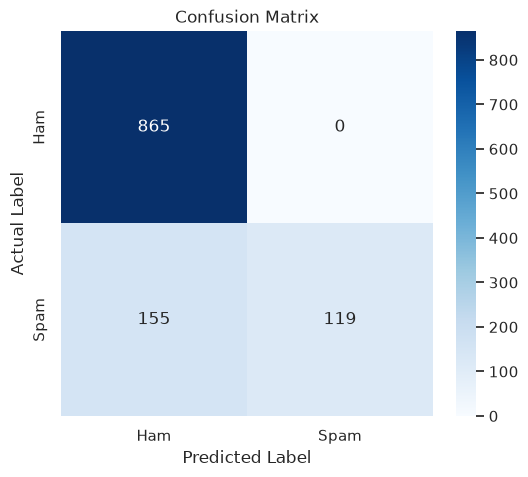

In [1187]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels= ["Ham", "Spam"],
    yticklabels= ["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [1188]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision: ", precision)

Precision:  1.0


In [1189]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", f"{recall * 100: .1f}%")

Recall:  43.4%


In [1190]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1-score: ", f"{f1 * 100: .1f}%")

F1-score:   60.6%


In [1191]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.85      1.00      0.92       865
        Spam       1.00      0.43      0.61       274

    accuracy                           0.86      1139
   macro avg       0.92      0.72      0.76      1139
weighted avg       0.88      0.86      0.84      1139



In [1192]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8639
Precision: 1.0000
Recall   : 0.4343
F1-score : 0.6056


In [1193]:
vectorizer = TfidfVectorizer()

In [1194]:
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

for alpha in [0.01, 0.1, 0.5, 1.0, 2.0]:
    model = MultinomialNB(alpha=alpha)

    model.fit(x_train_tfidf, y_train)

    y_pred = model.predict(x_test_tfidf)

    print(f"\n{'=' * 50}")
    print(f"Alpha: {alpha}")
    print('=' * 50)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Ham", "Spam"]
        )
    )


Alpha: 0.01
              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00       865
        Spam       1.00      0.98      0.99       274

    accuracy                           0.99      1139
   macro avg       0.99      0.99      0.99      1139
weighted avg       0.99      0.99      0.99      1139


Alpha: 0.1
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       865
        Spam       1.00      0.96      0.98       274

    accuracy                           0.99      1139
   macro avg       0.99      0.98      0.99      1139
weighted avg       0.99      0.99      0.99      1139


Alpha: 0.5
              precision    recall  f1-score   support

         Ham       0.90      1.00      0.95       865
        Spam       1.00      0.67      0.80       274

    accuracy                           0.92      1139
   macro avg       0.95      0.83      0.88      1139
weighted avg       0.93      0.92    

In [1195]:
best_model = MultinomialNB(alpha= 0.01)

best_model.fit(x_train_tfidf, y_train)

y_pred_best = best_model.predict(x_test_tfidf)

In [1196]:
cm = confusion_matrix(y_test, y_pred_best)

print(cm)


[[864   1]
 [  6 268]]


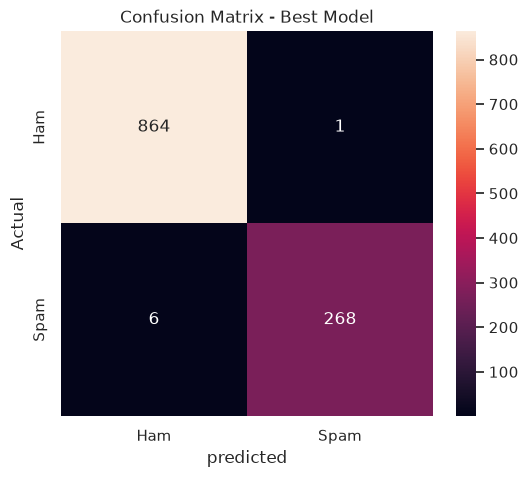

In [1197]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    xticklabels= ["Ham", "Spam"],
    yticklabels= ["Ham", "Spam"]
)

plt.title("Confusion Matrix - Best Model")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()

In [1203]:
from src.evaluation.metrics import evaluate_model, get_classification_report

accuracy_best = evaluate_model(y_test, y_pred_best)['Accuracy']
precision_best = evaluate_model(y_test, y_pred_best)['Precision']
recall_best = evaluate_model(y_test, y_pred_best)['Recall']
f1_best = evaluate_model(y_test, y_pred_best)['F1']

print(f"Accuracy : {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall   : {recall_best:.4f}")
print(f"F1-score : {f1_best:.4f}")

Accuracy : 0.9939
Precision: 0.9963
Recall   : 0.9781
F1-score : 0.9871


In [1205]:
alphas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

In [1206]:
for alpha in alphas:

    model = MultinomialNB(alpha=alpha)

    model.fit(x_train_tfidf, y_train)

    predictions = model.predict(x_test_tfidf)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(
        f"alpha={alpha:<5} "
        f"accuracy={accuracy:.4f} "
        f"precision={precision:.4f} "
        f"recall={recall:.4f} "
        f"f1={f1:.4f}"
    )

alpha=0.001 accuracy=0.9912 precision=1.0000 recall=0.9635 f1=0.9814
alpha=0.005 accuracy=0.9930 precision=0.9963 recall=0.9745 f1=0.9852
alpha=0.01  accuracy=0.9939 precision=0.9963 recall=0.9781 f1=0.9871
alpha=0.02  accuracy=0.9930 precision=0.9963 recall=0.9745 f1=0.9852
alpha=0.05  accuracy=0.9939 precision=1.0000 recall=0.9745 f1=0.9871
alpha=0.1   accuracy=0.9903 precision=1.0000 recall=0.9599 f1=0.9795
